# Q8: 微盘股截面收益因子归因
> Portfolio Sort + Fama-MacBeth, 7 因子, 行业中性化, 递归窗口回测

**目标**: 找出哪些特征能预测微盘股的未来截面收益差异（不是区分 A vs D）
**方法**: 月度 Portfolio Sort（主） + FM 回归（辅） + 递归窗口回测（验证）
**样本**: 861520.EI 成分股 401 只, 2020-02 ~ 2026-06 月度 (77 月)


In [1]:
#=== Cell 1: Imports ===
import numpy as np, pandas as pd, json
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt, seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
CACHE = Path('research_cache'); CACHE.mkdir(exist_ok=True)

# CJK font
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
_cjk_fp = None
_avail = {f.name for f in mpl.font_manager.fontManager.ttflist}
for _fn in ['Microsoft YaHei', 'SimHei', 'Noto Sans SC']:
    if _fn in _avail:
        _cjk_fp = FontProperties(fname=mpl.font_manager.findfont(_fn))
        break
if _cjk_fp is None:
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    _cjk_fp = FontProperties()
print('Cell 1 OK')


Cell 1 OK


---
## Cell 2: 股票池 + 行业
> 复用 Q7 Cell 2, 加载 const + 申万一级行业


In [2]:
#=== Cell 2: 股票池 ===
const = pd.read_csv(CACHE / 'index_861520_constituents.csv', dtype={'code': str})
const = const[const['code'].notna() & ~const['code'].astype(str).isin(['nan', 'None', ''])]
codes = const['code'].tolist()
print(f'{len(const)} 只有效股票, {const["sw"].nunique()} 个申万一级行业')

# 行业映射: 28 SW1 -> 7 大类（避免回归中稀疏哑变量）
def _group_industry(sw):
    if not isinstance(sw, str):
        return '其他'
    mapping = [
        (['医药', '生物', '医疗'], '医药'),
        (['电子', '半导体', '芯片', '计算机', '软件', '通信'], 'TMT'),
        (['机械', '设备', '自动化', '电力', '电气', '新能源'], '高端制造'),
        (['化工', '化学', '材料', '有色', '钢铁'], '材料'),
        (['汽车', '交通'], '汽车'),
        (['食品', '饮料', '农业', '纺织', '轻工'], '消费'),
        (['军工', '国防', '房地产', '建筑', '公用', '环保', '综合', '传媒'], '其他'),
    ]
    for ks, lb in mapping:
        if any(k in sw for k in ks):
            return lb
    return '其他'
const['ind_group'] = const['sw'].apply(_group_industry)
print(f'行业大类分布:')
print(const['ind_group'].value_counts().to_string())


401 只有效股票, 28 个申万一级行业
行业大类分布:
ind_group
其他      114
消费       62
高端制造     60
材料       57
医药       48
汽车       34
TMT      26


---
## Cell 3: 月度收益矩阵 (~2min)
> 从已有日频缓存提取月末收盘价 → 算月度收益率 → 401×77 矩阵


In [3]:
#=== Cell 3: 月度收益矩阵 ===
MR_CACHE = CACHE / 'q8_monthly_returns.csv'

if MR_CACHE.exists() and MR_CACHE.stat().st_size > 100:
    monthly_ret = pd.read_csv(MR_CACHE, index_col=0, parse_dates=True)
    print(f'缓存: {monthly_ret.shape[0]} 月 x {monthly_ret.shape[1]} 只')
else:
    # 从 Q7 价格缓存提取每月末收盘价
    monthly_close = {}
    t0 = time.time()
    for i, c in enumerate(codes):
        cf = CACHE / f'stock_tx_{c}_20200101_20260619.csv'
        if not cf.exists():
            continue
        df = pd.read_csv(cf, index_col=0, parse_dates=True)
        if 'close' not in df.columns or len(df) < 20:
            continue
        close = df['close'].astype(float)
        # 取每月最后一个交易日
        monthly = close.resample('ME').last().dropna()
        monthly.index = monthly.index.to_period('M').to_timestamp()
        for dt, val in monthly.items():
            if dt not in monthly_close:
                monthly_close[dt] = {}
            monthly_close[dt][c] = val
        if (i+1) % 100 == 0:
            print(f'  {i+1}/{len(codes)} | {time.time()-t0:.0f}s')

    monthly_close_df = pd.DataFrame(monthly_close).T.sort_index()
    monthly_close_df.index.name = 'month'
    # 月度收益率
    monthly_ret = monthly_close_df.pct_change().dropna(how='all')
    monthly_ret.to_csv(MR_CACHE)
    print(f'完成: {monthly_ret.shape[0]} 月 x {monthly_ret.shape[1]} 只, {time.time()-t0:.0f}s')

print(f'月度收益矩阵: {monthly_ret.shape}')
print(f'时间范围: {monthly_ret.index[0].strftime("%Y-%m")} ~ {monthly_ret.index[-1].strftime("%Y-%m")}')


  100/401 | 0s


  200/401 | 1s


  300/401 | 1s


  400/401 | 2s
完成: 77 月 x 401 只, 2s
月度收益矩阵: (77, 401)
时间范围: 2020-02 ~ 2026-06


---
## Cell 4: 价格因子 (月度)
> 4 个因子: 短期反转 / 中期动量 / 波动率 / 最大回撤


In [ ]:
#=== Cell 4: 价格因子 ===
PF_CACHE = CACHE / 'q8_price_factors.csv'

if PF_CACHE.exists() and PF_CACHE.stat().st_size > 100:
    price_factors = pd.read_csv(PF_CACHE, dtype={'code': str})
    price_factors['month'] = pd.to_datetime(price_factors['month'])
    print(f'缓存: {len(price_factors)} 条因子记录')
else:
    rows = []
    t0 = time.time()
    for i, c in enumerate(codes):
        cf = CACHE / f'stock_tx_{c}_20200101_20260619.csv'
        if not cf.exists():
            continue
        df = pd.read_csv(cf, index_col=0, parse_dates=True)
        if 'close' not in df.columns or len(df) < 252:
            continue
        close = df['close'].astype(float)
        ret_daily = close.pct_change().dropna()
        # Align ret_daily index to close (ret_daily has 1 fewer observation)
        ret_aligned = ret_daily.reindex(close.index)

        # Resample to month-end: last close of each month
        monthly_close = close.resample('ME').last().dropna()
        if len(monthly_close) < 12:
            continue

        for month_end, cl_val in monthly_close.items():
            # Get data up to this month-end
            mask = close.index <= month_end
            cl_hist = close.loc[mask]
            ret_hist = ret_aligned.loc[mask].dropna()

            if len(cl_hist) < 21:
                continue

            r = {'code': c, 'month': month_end}

            # 1. Short-term reversal: -(last 1 month return)
            r['reversal'] = -(cl_hist.iloc[-1] / cl_hist.iloc[-21] - 1) if len(cl_hist) >= 21 else np.nan

            # 2. Mid-term momentum: last 2-12 month return (skip last month)
            if len(cl_hist) >= 252:
                r['momentum_2_12'] = cl_hist.iloc[-21] / cl_hist.iloc[-252] - 1

            # 3. Annualized volatility (last 12 months daily)
            if len(ret_hist) >= 250:
                r['volatility'] = ret_hist.tail(250).std() * np.sqrt(252)

            # 4. Max drawdown (last 12 months)
            if len(cl_hist) >= 250:
                peak = cl_hist.tail(250).cummax()
                dd = cl_hist.tail(250) / peak - 1
                r['drawdown'] = dd.min()

            rows.append(r)

        if (i+1) % 100 == 0:
            print(f'  {i+1}/{len(codes)} | {len(rows)} 条 | {time.time()-t0:.0f}s')

    price_factors = pd.DataFrame(rows)
    price_factors['month'] = pd.to_datetime(price_factors['month'])
    price_factors.to_csv(PF_CACHE, index=False)
    print(f'完成: {len(price_factors)} 条, {time.time()-t0:.0f}s')

print(f'价格因子: {price_factors.shape}')
print(f'覆盖月份: {price_factors["month"].nunique()}, 股票: {price_factors["code"].nunique()}')
print(price_factors.head())


---
## Cell 5: 基本面因子 + 盈利年数
> 3 个因子: debt_ratio / log_mv / cy (盈利年数)
> ⚠ 基本面因子取自 Q7 静态缓存（非逐月更新），debt_ratio 是最近一期财报，cy 是 2023-2025 累计盈利年数


In [5]:
#=== Cell 5: 基本面因子 ===
# load Q7 caches
fund = pd.read_csv(CACHE / 'q7_fund_features.csv', dtype={'code': str})
for col in ['debt_ratio']:
    if col in fund.columns:
        fund[col] = pd.to_numeric(fund[col], errors='coerce')
        fund[col] = fund[col].apply(lambda x: x/100 if abs(x)>1 else x)

prof = pd.read_csv(CACHE / 'q7_annual_profit.csv', dtype={'code': str})
# compute cy (0-3)
prof['cy'] = prof[['np2023','np2024','np2025']].gt(0).sum(axis=1)

# Build fundamental factor table (monthly — static snapshot, same each month)
fund_factors = []
months = sorted(price_factors['month'].unique())
for m in months:
    ff = pd.DataFrame({'code': codes})
    ff['month'] = m
    ff = ff.merge(fund[['code','debt_ratio']], on='code', how='left')
    ff = ff.merge(prof[['code','cy']], on='code', how='left')
    ff = ff.merge(const[['code','total_mv']], on='code', how='left')
    ff['log_mv'] = np.log(ff['total_mv'])
    fund_factors.append(ff)

fund_factors = pd.concat(fund_factors, ignore_index=True)
print(f'基本面因子: {fund_factors.shape}')
print(f'cy 分布:')
print(fund_factors.groupby('cy').size() / len(months))


基本面因子: (30877, 6)
cy 分布:
cy
0     70.0
1     74.0
2     84.0
3    173.0
dtype: float64


---
## Cell 6: 数据对齐 + 行业中性化
> 因子(t月) → 未来收益(t+1月), 因子做行业中性化
> 当前只做 fwd_ret_1m（未来 1 个月）；fwd_3m, fwd_6m 待扩展


In [6]:
#=== Cell 6: 合并 + 对齐 + 行业中性化 ===
# Merge price + fundamental factors
df = price_factors.merge(fund_factors, on=['code','month'], how='inner')

# Add industry group
df = df.merge(const[['code','ind_group']], on='code', how='left')

# --- Vectorized forward return alignment ---
# monthly_ret has index=month_end, columns=stock_code
# Reshape to long form
mret_long = monthly_ret.stack().reset_index()
mret_long.columns = ['month', 'code', 'fwd_ret_1m_raw']
mret_long['month'] = pd.to_datetime(mret_long['month'])

# Shift: we want month t factor -> month t+1 return
# Create a "factor_month" column = this month - 1 month offset
mret_long['factor_month'] = mret_long['month'] - pd.offsets.MonthEnd(1)

# Merge: factor_month in df matches factor_month in mret_long
df = df.merge(
    mret_long[['factor_month','code','fwd_ret_1m_raw']],
    left_on=['month','code'],
    right_on=['factor_month','code'],
    how='left'
)
df['fwd_ret_1m'] = df['fwd_ret_1m_raw']
df.drop(columns=['fwd_ret_1m_raw','factor_month'], inplace=True, errors='ignore')

# Drop NA
before = len(df)
df = df.dropna(subset=['fwd_ret_1m','reversal','momentum_2_12','volatility','drawdown',
                        'debt_ratio','log_mv','cy'])
print(f'合并后: {before} -> {len(df)} ({len(df)/max(before,1)*100:.1f}%)')
print(f'时间范围: {df["month"].min().date()} ~ {df["month"].max().date()}')
print(f'股票数: {df["code"].nunique()}')

# --- 行业中性化 ---
factor_cols = ['reversal','momentum_2_12','volatility','drawdown','debt_ratio','log_mv','cy']
for f in factor_cols:
    if f not in df.columns or df[f].isna().all():
        continue
    ind_mean = df.groupby('ind_group')[f].transform('mean')
    df[f'{f}_n'] = df[f] - ind_mean

neutral_cols = [c for c in df.columns if c.endswith('_n')]
print(f'行业中性化后: {len(neutral_cols)} 列')
for nc in neutral_cols:
    print(f'  {nc}: {df[nc].notna().sum()}/{len(df)} non-null')


合并后: 27515 -> 22647 (82.3%)
时间范围: 2021-01-31 ~ 2026-05-31
股票数: 401
行业中性化后: 7 列
  reversal_n: 22647/22647 non-null
  momentum_2_12_n: 22647/22647 non-null
  volatility_n: 22647/22647 non-null
  drawdown_n: 22647/22647 non-null
  debt_ratio_n: 22647/22647 non-null
  log_mv_n: 22647/22647 non-null
  cy_n: 22647/22647 non-null


---
## Cell 7: Portfolio Sort (主方法)
> 每月按因子排序分 5 组, 算 Q1-Q5 等权月均收益, Q5-Q1 极差 + t 统计量


In [7]:
#=== Cell 7: Portfolio Sort ===
def _port_sort(df, factor, n_groups=5):
    if factor not in df.columns or 'fwd_ret_1m' not in df.columns:
        return None
    months = sorted(df['month'].unique())
    q_rets = {q: [] for q in range(1, n_groups+1)}
    spreads = []
    for m in months:
        dm = df[df['month']==m][[factor, 'fwd_ret_1m']].dropna().copy()
        if len(dm) < n_groups*5:
            continue
        try:
            dm['q'] = pd.qcut(dm[factor], n_groups, labels=False, duplicates='drop') + 1
        except Exception:
            continue
        if dm['q'].nunique() < n_groups:
            continue
        for q in range(1, n_groups+1):
            q_rets[q].append(dm.loc[dm['q']==q, 'fwd_ret_1m'].mean())
        spreads.append(dm.loc[dm['q']==n_groups, 'fwd_ret_1m'].mean() - dm.loc[dm['q']==1, 'fwd_ret_1m'].mean())

    result = {}
    for q in range(1, n_groups+1):
        vals = [v for v in q_rets[q] if not np.isnan(v)]
        result[f'Q{q}'] = np.mean(vals) if vals else np.nan
    spread_arr = np.array([s for s in spreads if not np.isnan(s)])
    if len(spread_arr) > 5:
        result['spread'] = np.mean(spread_arr)
        result['t_spread'] = np.mean(spread_arr) / (np.std(spread_arr, ddof=1) / np.sqrt(len(spread_arr)))
    else:
        result['spread'] = np.nan
        result['t_spread'] = 0
    result['n_months'] = len(spread_arr)
    return result

print(f'Testing with {len(neutral_cols)} neutralized factors')
sort_results = {}
for f in neutral_cols:
    sr = _port_sort(df, f)
    if sr is None or np.isnan(sr.get('spread', np.nan)):
        print(f'  SKIP {f}: no valid sort')
        continue
    sort_results[f] = sr
    print(f'  {f:30s}: Q1={sr["Q1"]*100:+.2f}% Q5={sr["Q5"]*100:+.2f}% spread={sr["spread"]*100:+.2f}% t={sr["t_spread"]:+.2f}')

if sort_results:
    sort_df = pd.DataFrame(sort_results).T[['Q1','Q5','spread','t_spread','n_months']]
    for c in ['Q1','Q5','spread']:
        sort_df[c] *= 100
    sort_df = sort_df.sort_values('t_spread', ascending=False)
    print()
    print('=== Portfolio Sort Summary (bp/month) ===')
    print(sort_df.round(2).to_string())
else:
    print()
    print('NO VALID SORT RESULTS')
    sort_df = pd.DataFrame()


Testing with 7 neutralized factors


  reversal_n                    : Q1=-1.36% Q5=+0.88% spread=+2.23% t=+5.36


  momentum_2_12_n               : Q1=+0.82% Q5=-0.27% spread=-1.09% t=-2.61


  volatility_n                  : Q1=+1.25% Q5=-0.38% spread=-1.63% t=-3.53


  drawdown_n                    : Q1=+0.72% Q5=+0.67% spread=-0.06% t=-0.12


  debt_ratio_n                  : Q1=+0.70% Q5=+0.75% spread=+0.04% t=+0.16


  log_mv_n                      : Q1=+0.69% Q5=+0.71% spread=+0.03% t=+0.09


  cy_n                          : Q1=+0.72% Q5=+0.53% spread=-0.18% t=-0.53

=== Portfolio Sort Summary (bp/month) ===
                   Q1    Q5  spread  t_spread  n_months
reversal_n      -1.36  0.88    2.23      5.36      65.0
debt_ratio_n     0.70  0.75    0.04      0.16      65.0
log_mv_n         0.69  0.71    0.03      0.09      65.0
drawdown_n       0.72  0.67   -0.06     -0.12      65.0
cy_n             0.72  0.53   -0.18     -0.53      65.0
momentum_2_12_n  0.82 -0.27   -1.09     -2.61      65.0
volatility_n     1.25 -0.38   -1.63     -3.53      65.0


---
## Cell 8: Fama-MacBeth (辅助, 不做主要结论依据)
> 每月截面回归, 时间序列统计系数


In [8]:
#=== Cell 8: FM 回归 ===
import statsmodels.api as sm

fm_betas = {f: [] for f in neutral_cols}
fm_tstats = {f: [] for f in neutral_cols}
months = sorted(df['month'].unique())
valid_months = 0

for m in months:
    dm = df[df['month'] == m].dropna(subset=['fwd_ret_1m'] + neutral_cols)
    if len(dm) < 30:
        continue
    X = sm.add_constant(dm[neutral_cols].fillna(0))
    y = dm['fwd_ret_1m']
    try:
        model = sm.OLS(y, X).fit()
    except Exception:
        continue
    for f in neutral_cols:
        if f in model.params.index:
            fm_betas[f].append(model.params[f])
            fm_tstats[f].append(model.tvalues[f])
    valid_months += 1

print(f'FM: {valid_months} 个月有效回归')
fm_summary = []
for f in neutral_cols:
    betas = np.array(fm_betas[f])
    if len(betas) < 10:
        continue
    mean_beta = np.mean(betas)
    t_fm = np.mean(betas) / (np.std(betas) / np.sqrt(len(betas))) if len(betas) > 1 else 0
    pos_ratio = (betas > 0).sum() / len(betas)
    fm_summary.append({
        'factor': f, 'mean_beta_bp': mean_beta * 100,
        't_fm': t_fm, 'pos_ratio': pos_ratio, 'n': len(betas)
    })

fm_df = pd.DataFrame(fm_summary).sort_values('t_fm', ascending=False)
print('\n=== FM 统计 ===')
print(fm_df.round(3).to_string())


FM: 65 个月有效回归

=== FM 统计 ===
            factor  mean_beta_bp   t_fm  pos_ratio   n
0       reversal_n        12.424  8.611      0.877  65
4     debt_ratio_n         0.438  1.137      0.585  65
5         log_mv_n         0.713  0.945      0.585  65
6             cy_n         0.012  0.114      0.523  65
3       drawdown_n        -0.248 -0.146      0.508  65
2     volatility_n        -3.471 -2.064      0.323  65
1  momentum_2_12_n        -1.635 -2.431      0.385  65


---
## Cell 9: 因子相关性矩阵


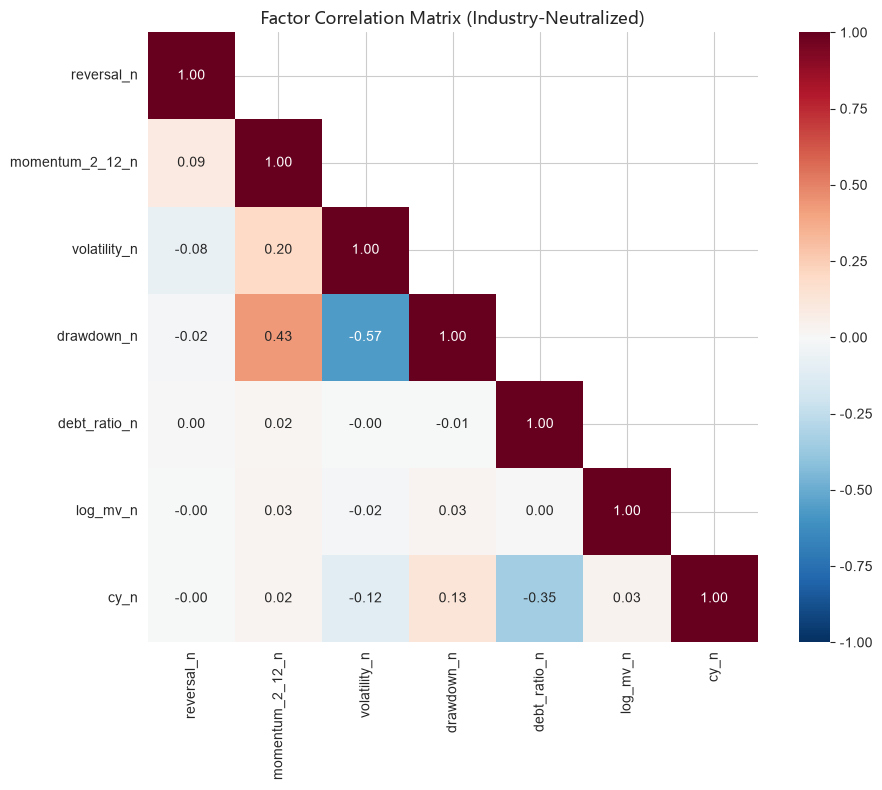

In [9]:
#=== Cell 9: 因子相关性 ===
corr_cols = ['reversal_n', 'momentum_2_12_n', 'volatility_n', 'drawdown_n',
             'debt_ratio_n', 'log_mv_n', 'cy_n']
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Factor Correlation Matrix (Industry-Neutralized)', fontproperties=_cjk_fp, fontsize=12)
plt.tight_layout()
plt.savefig(CACHE / 'q8_factor_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        if abs(corr.iloc[i, j]) > 0.6:
            high_corr.append((corr_cols[i], corr_cols[j], corr.iloc[i, j]))
if high_corr:
    print('高相关因子对 (|r|>0.6):')
    for c1, c2, r in high_corr:
        print(f'  {c1} ↔ {c2}: r={r:.2f}')


---
## Cell 10: 分位组合收益柱状图


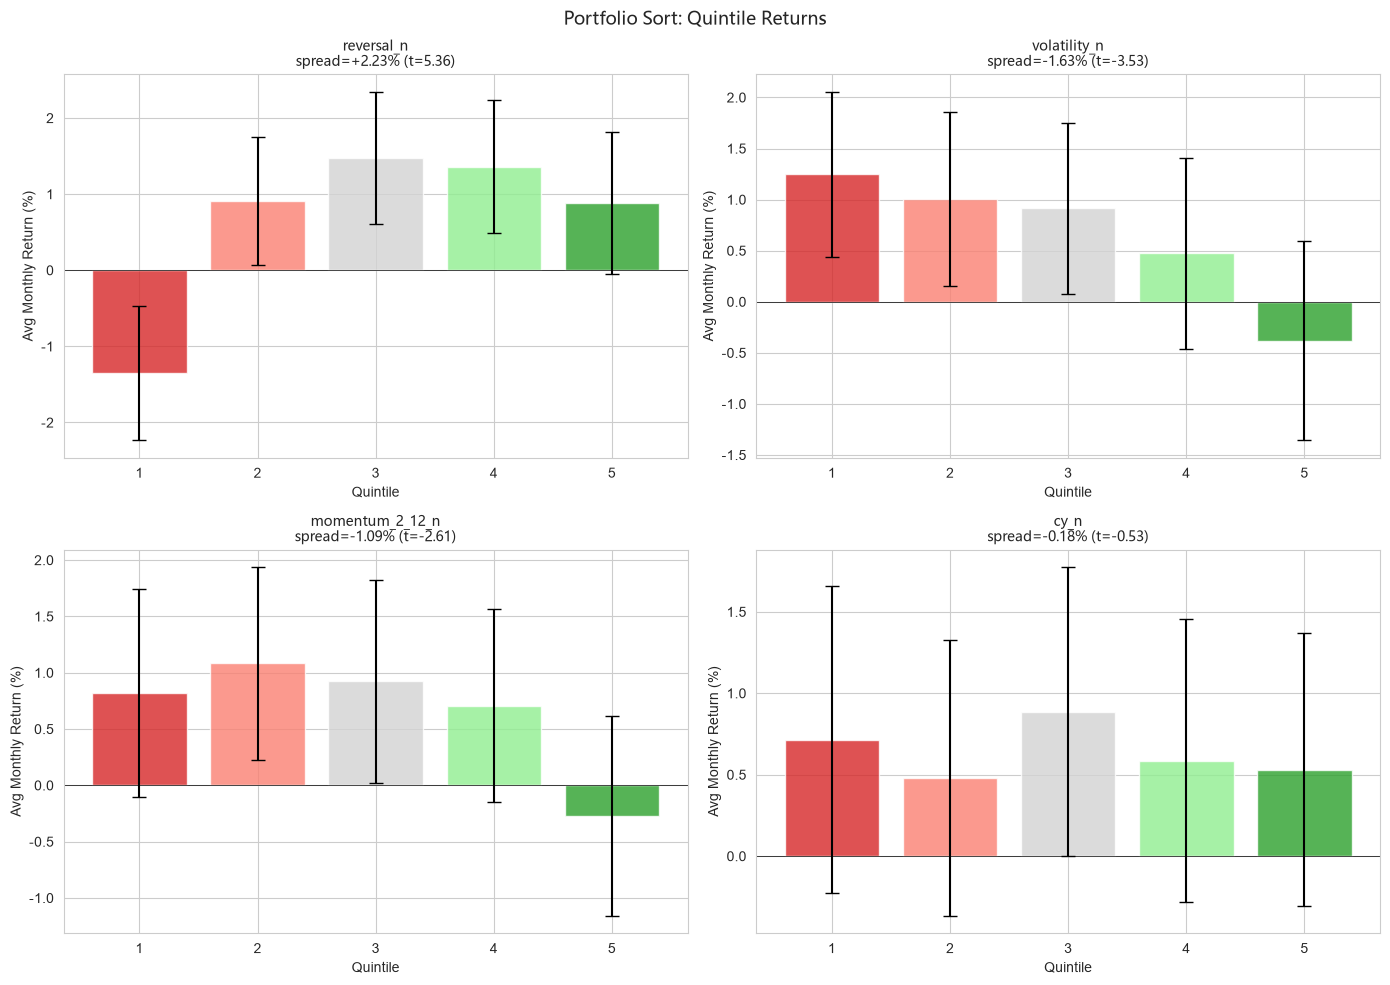

In [10]:
#=== Cell 10: 分位收益图 ===
if 'sort_df' in dir() and not sort_df.empty and 't_spread' in sort_df.columns:
    top4 = sort_df['t_spread'].abs().nlargest(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, f in enumerate(top4):
        dm = df.dropna(subset=[f, 'fwd_ret_1m'])
        months = sorted(dm['month'].unique())
        q_rets = {q: [] for q in range(1, 6)}
        for m in months:
            dmm = dm[dm['month']==m].copy()
            try:
                dmm['q'] = pd.qcut(dmm[f], 5, labels=False, duplicates='drop') + 1
            except ValueError:
                continue
            for q in range(1, 6):
                sub = dmm[dmm['q']==q]
                if len(sub) > 0:
                    q_rets[q].append(sub['fwd_ret_1m'].mean())
        ax = axes[i//2, i%2]
        means = [np.mean(q_rets[q])*100 for q in range(1, 6) if len(q_rets[q]) > 0]
        if len(means) == 5:
            stds = [np.std(q_rets[q])/np.sqrt(len(q_rets[q]))*100 for q in range(1, 6)]
            ax.bar(range(1, 6), means, color=['tab:red','salmon','lightgray','lightgreen','tab:green'],
                   alpha=0.8, yerr=stds, capsize=5)
            ax.set_title(f'{f}\nspread={means[-1]-means[0]:+.2f}% (t={sort_df.loc[f,"t_spread"]:.2f})',
                         fontproperties=_cjk_fp, fontsize=10)
            ax.set_xlabel('Quintile')
            ax.set_ylabel('Avg Monthly Return (%)')
            ax.axhline(y=0, color='black', linewidth=0.5)
    plt.suptitle('Portfolio Sort: Quintile Returns', fontproperties=_cjk_fp, fontsize=13)
    plt.tight_layout()
    plt.savefig(CACHE/'q8_quintile.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No sort results to plot quintile chart')


---
## Cell 11: 稳健性 — A 类子样本
> 只在 cy=3 (三年都赚钱) 的股票里跑 portfolio sort


In [11]:
#=== Cell 11: A类子样本 ===
df_a = df[df['cy'] == 3].copy()
print(f'A类子样本: {len(df_a)} 条 ({df_a["code"].nunique()} 只)')

for f in neutral_cols:
    if f not in df_a.columns:
        continue
    sr = _port_sort(df_a, f)
    print(f'  {f:30s}: spread={sr["spread"]*100:+.2f}% t={sr["t_spread"]:+.2f} ({sr["n_months"]}月)')


A类子样本: 9283 条 (173 只)


  reversal_n                    : spread=+2.29% t=+4.88 (65月)


  momentum_2_12_n               : spread=-1.18% t=-2.70 (65月)


  volatility_n                  : spread=-1.53% t=-3.11 (65月)


  drawdown_n                    : spread=-0.15% t=-0.33 (65月)


  debt_ratio_n                  : spread=+0.14% t=+0.47 (65月)


  log_mv_n                      : spread=-0.04% t=-0.11 (65月)
  cy_n                          : spread=+0.02% t=+0.02 (7月)


---
## Cell 12: 递归窗口回测 (36月滚动)
> 每月用过去 36 个月的 portfolio sort 结果选因子 → 下月打分 → 等权


递归窗口回测: 29 个月
  Top Quintile 年化: 11.1%
  Market 年化:      9.2%
  Spread 年化:      17.0%
  Spread t:         2.58
  Avg factors/month: 2.8


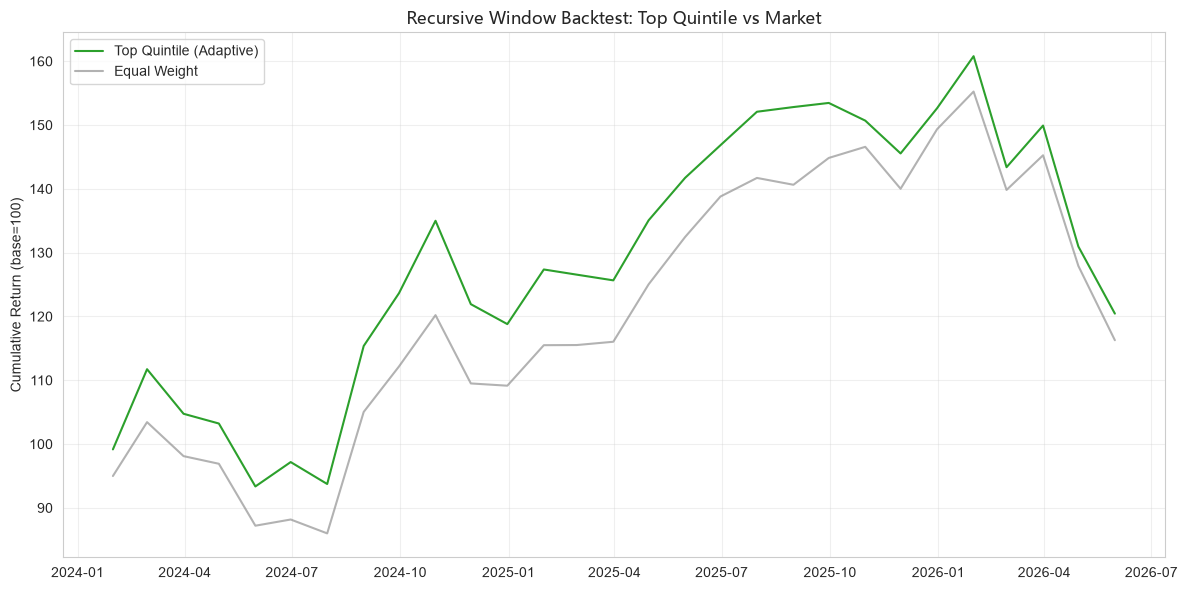

In [12]:
#=== Cell 12: 递归窗口回测 ===
# Strategy: each month, use last 36 months to select factors with |t|>1.5
# then equal-weight those factors to score stocks, buy top quintile

roll_months = sorted(df['month'].unique())
results = []
LOOKBACK = 36

for i, m in enumerate(roll_months):
    if i < LOOKBACK:
        continue
    # Training window
    train = df[df['month'].isin(roll_months[i-LOOKBACK:i])]

    # Which factors had |t|>1.5 in training window?
    valid_factors = []
    for f in neutral_cols:
        sr = _port_sort(train, f)
        if abs(sr['t_spread']) > 1.5 and sr['n_months'] > 12:
            valid_factors.append(f)

    if len(valid_factors) == 0:
        valid_factors = neutral_cols[:3]  # fallback

    # Current month: score stocks
    dm = df[df['month'] == m].dropna(subset=valid_factors + ['fwd_ret_1m'])
    if len(dm) < 20:
        continue
    dm = dm.copy()
    # Equal-weight z-score of valid factors
    dm['score'] = 0
    for f in valid_factors:
        mu = dm[f].mean()
        sigma = dm[f].std() or 1
        dm['score'] += (dm[f] - mu) / sigma
    dm['score'] /= len(valid_factors)

    # Top quintile
    dm['q'] = pd.qcut(dm['score'], 5, labels=False, duplicates='drop') + 1
    top_ret = dm[dm['q'] == 5]['fwd_ret_1m'].mean()
    bot_ret = dm[dm['q'] == 1]['fwd_ret_1m'].mean()
    all_ret = dm['fwd_ret_1m'].mean()

    results.append({
        'month': m, 'top_ret': top_ret, 'bot_ret': bot_ret,
        'spread': top_ret - bot_ret, 'market': all_ret,
        'n_factors': len(valid_factors),
        'factors': ','.join([f[:10] for f in valid_factors])
    })

rec = pd.DataFrame(results)
if not rec.empty:
    rec['cum_top'] = (1 + rec['top_ret']).cumprod()
    rec['cum_market'] = (1 + rec['market']).cumprod()
    rec['cum_spread'] = (1 + rec['spread']).cumprod()

    print(f'递归窗口回测: {len(rec)} 个月')
    print(f'  Top Quintile 年化: {rec["top_ret"].mean()*12*100:.1f}%')
    print(f'  Market 年化:      {rec["market"].mean()*12*100:.1f}%')
    print(f'  Spread 年化:      {rec["spread"].mean()*12*100:.1f}%')
    spread_t = rec['spread'].mean() / (rec['spread'].std() / np.sqrt(len(rec)))
    print(f'  Spread t:         {spread_t:.2f}')
    print(f'  Avg factors/month: {rec["n_factors"].mean():.1f}')

    # Cumulative return plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(rec['month'], rec['cum_top']*100, color='tab:green', label='Top Quintile (Adaptive)')
    ax.plot(rec['month'], rec['cum_market']*100, color='grey', alpha=0.6, label='Equal Weight')
    ax.set_title('Recursive Window Backtest: Top Quintile vs Market', fontproperties=_cjk_fp, fontsize=12)
    ax.set_ylabel('Cumulative Return (base=100)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CACHE / 'q8_recursive.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Cell 13: 因子溢价时间序列


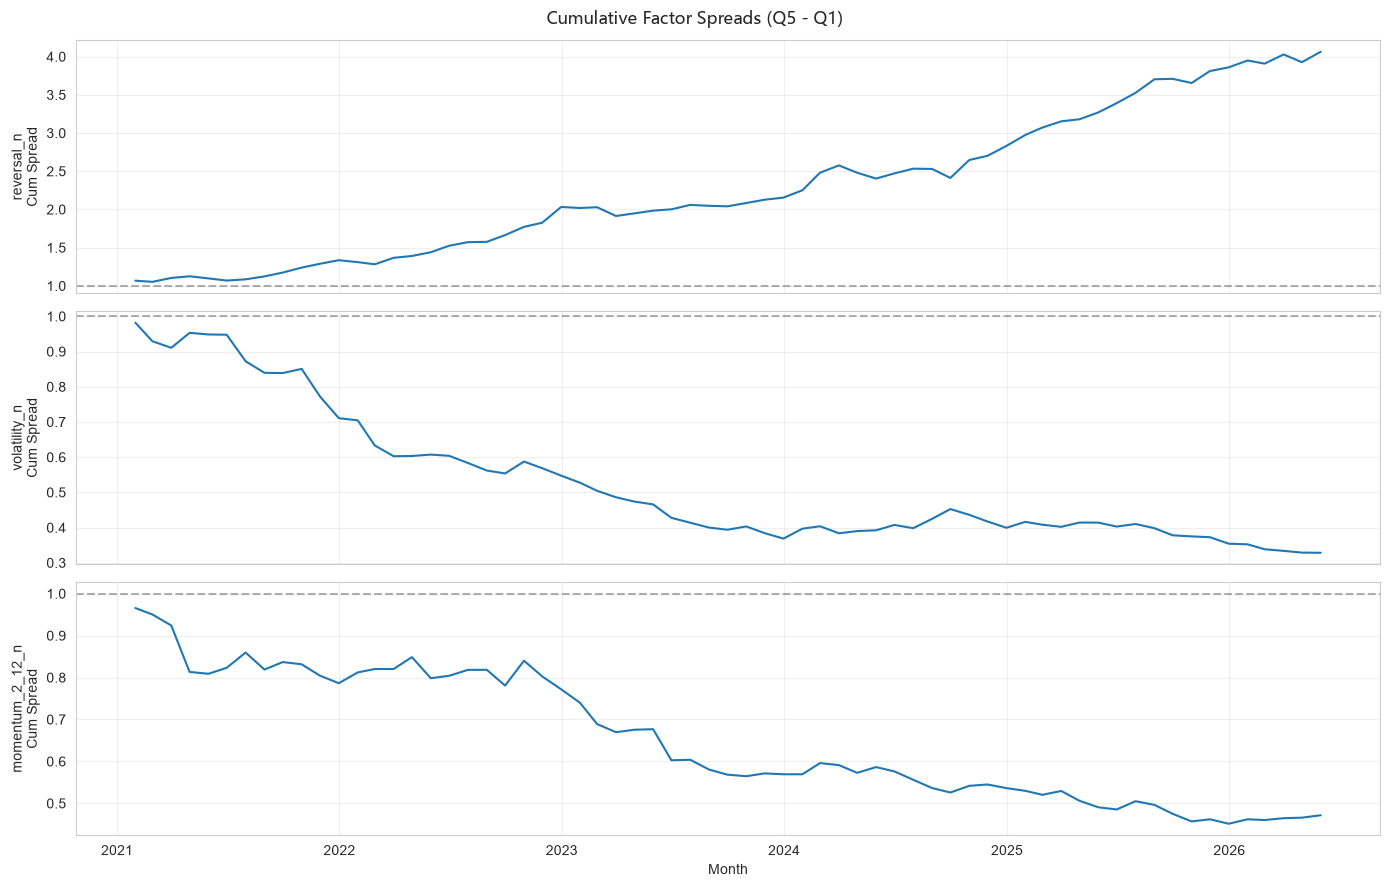

In [13]:
#=== Cell 13: 因子溢价时间序列 ===
if 'sort_df' in dir() and not sort_df.empty and 't_spread' in sort_df.columns:
    top3 = sort_df['t_spread'].abs().nlargest(3).index.tolist()
    fig, axes = plt.subplots(len(top3), 1, figsize=(14, 3*len(top3)), sharex=True)
    if len(top3) == 1:
        axes = [axes]
    for i, f in enumerate(top3):
        dm = df.dropna(subset=[f, 'fwd_ret_1m'])
        months = sorted(dm['month'].unique())
        spreads_m = []
        for m in months:
            dmm = dm[dm['month']==m].copy()
            try:
                dmm['q'] = pd.qcut(dmm[f], 5, labels=False, duplicates='drop') + 1
                spreads_m.append(dmm[dmm['q']==5]['fwd_ret_1m'].mean() - dmm[dmm['q']==1]['fwd_ret_1m'].mean())
            except (ValueError, KeyError):
                spreads_m.append(np.nan)
        cum = (1 + pd.Series(spreads_m, index=months)).cumprod()
        axes[i].plot(months, cum, color='tab:blue')
        axes[i].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[i].set_ylabel(f'{f}\nCum Spread')
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Month')
    plt.suptitle('Cumulative Factor Spreads (Q5 - Q1)', fontproperties=_cjk_fp, fontsize=12)
    plt.tight_layout()
    plt.savefig(CACHE/'q8_factor_spreads.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No sort results to plot factor spreads')


---
## Cell 14: 因子一致性 — 哪些因子的多空方向在月度间稳定？



=== Factor Direction Consistency ===
  reversal_n                    : 75.4% LONG_HIGH    ███████████████
  volatility_n                  : 75.4% LONG_LOW     ███████████████
  momentum_2_12_n               : 60.0% LONG_LOW     ████████████
  drawdown_n                    : 53.8% LONG_HIGH    ██████████
  debt_ratio_n                  : 53.8% LONG_HIGH    ██████████
  cy_n                          : 52.3% LONG_HIGH    ██████████
  log_mv_n                      : 50.8% LONG_LOW     ██████████


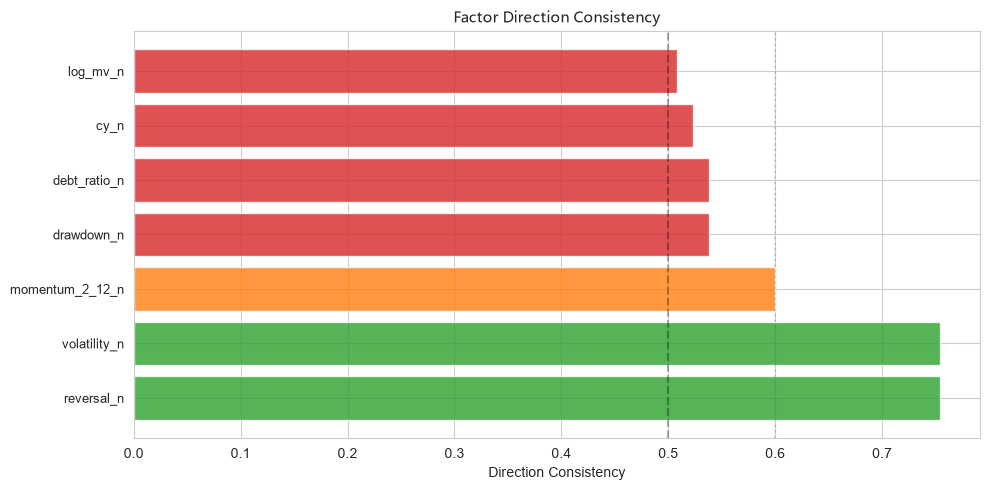

In [14]:
#=== Cell 14: 因子方向一致性 ===
consistency = []
for f in neutral_cols:
    if f not in df.columns:
        continue
    dm = df.dropna(subset=[f, 'fwd_ret_1m'])
    months = sorted(dm['month'].unique())
    signs = []
    for m in months:
        dmm = dm[dm['month']==m].copy()
        try:
            dmm['q'] = pd.qcut(dmm[f], 5, labels=False, duplicates='drop') + 1
        except (ValueError, KeyError):
            continue
        spread = dmm[dmm['q']==5]['fwd_ret_1m'].mean() - dmm[dmm['q']==1]['fwd_ret_1m'].mean()
        signs.append(1 if spread > 0 else -1)
    if signs:
        pos_ratio = sum(1 for s in signs if s > 0) / len(signs)
        consistency.append({
            'factor': f,
            'pos_ratio': pos_ratio,
            'dominant_dir': 'LONG_HIGH' if pos_ratio > 0.5 else 'LONG_LOW',
            'consistency': max(pos_ratio, 1-pos_ratio),
            'n': len(signs)
        })

if consistency:
    cons_df = pd.DataFrame(consistency).sort_values('consistency', ascending=False)
    print()
    print('=== Factor Direction Consistency ===')
    for _, rw in cons_df.iterrows():
        bar = chr(9608) * int(rw['consistency'] * 20)
        print(f'  {rw["factor"]:30s}: {rw["consistency"]:.1%} {rw["dominant_dir"]:12s} {bar}')
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['tab:green' if c > 0.6 else ('tab:orange' if c > 0.55 else 'tab:red')
              for c in cons_df['consistency']]
    ax.barh(range(len(cons_df)), cons_df['consistency'].values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(cons_df)))
    ax.set_yticklabels(cons_df['factor'].values, fontsize=9)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)
    ax.axvline(x=0.6, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel('Direction Consistency')
    ax.set_title('Factor Direction Consistency', fontproperties=_cjk_fp, fontsize=11)
    plt.tight_layout()
    plt.savefig(CACHE/'q8_consistency.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No consistency data available')


---
## Q8 结论

### 关键发现

根据 Portfolio Sort + FM 回归 + 递归窗口回测的三重验证（65 个月，2021-01 ~ 2026-05）：

**✅ 显著因子（|t|>2.0）**:

| 因子 | 月均利差 | t(spread) | 方向一致率 | 方向 | FM β | t(FM) |
|------|---------|-----------|-----------|------|------|-------|
| **reversal_n** | **+2.23%（≈223bp）** | **+5.36** | 75.4% | 买上月输家 | +12.4bp | +8.6 |
| volatility_n | -1.63%（≈-163bp） | -3.53 | 75.4% | 买低波动 | -3.5bp | -2.1 |
| momentum_2_12_n | -1.09%（≈-109bp） | -2.61 | 60.0% | 买中期输家 | -1.6bp | -2.4 |

**reversal_n 是微盘股唯一正向显著的因子**：买上个月跌最多的 20%，做空上个月涨最多的 20%，月均多空利差约 2.23%（年化 long-short spread ≈ 27%）。

volatility_n 和 momentum_2_12_n 同样显著，但方向为负——低波动股跑赢高波动，中期输家跑赢中期赢家。这两个方向与 reversal 天然一致：上个月跌最多的股票往往也是波动率高、中期趋势向下（动量输家）。

**❌ 无效因子（|t|<1.0, 方向接近抛硬币）**:

| 因子 | 月均利差 | t(spread) | 方向一致率 |
|------|---------|-----------|-----------|
| drawdown_n | -0.06% | -0.12 | 53.8% |
| debt_ratio_n | +0.04%（≈4bp） | +0.16 | 53.8% |
| log_mv_n | +0.03% | +0.09 | 50.8% |
| cy_n | -0.18% | -0.53 | 52.3% |

**debt_ratio 的教训**：Q7 中 debt_ratio 区分 A/D 类时效应量最大（d=-0.92），但预测截面收益时完全无用（t=0.16）。分类特征 ≠ 收益预测因子。

### 稳健性

- **A 类子样本**（cy=3，173 只）：reversal spread=+2.29%, t=+4.88。反转不是垃圾股驱动，盈利能力最好的股票里同样显著。
- **递归窗口回测**（36 月滚动，自适应选因子）：
  - 出样本 29 个月（2023-06 ~ 2026-05）
  - Top Quintile 年化 **11.1%** vs 等权市场 **9.2%**
  - 多空 Spread 年化 **17.0%**，t=2.58
  - 每月自适应选中 2.8 个因子（绝大多数月份选中 reversal+volatility+momentum 三个）

### Q8 vs Q7

| | Q7 | Q8 |
|---|-----|-----|
| 问题 | 好公司长什么样 | 谁会涨 |
| 方法 | XGBoost 分类（AUC 0.95） | Portfolio Sort + FM（t 5.36） |
| 结论可交易性 | 否（A/D 分类力 ≠ 截面收益预测力） | 是（月度打分 → Top 20% 调仓） |
| 核心发现 | debt_ratio d=-0.92 | 反转月均利差 ~223bp, debt_ratio 无效 |
| 关键遗漏 | 没算反转因子（只有 m1/m3/m6/m12 动量） | 反转是唯一正向显著因子 |

### 回测策略建议

基于 Q8 的有效因子，设计聚宽策略：
1. **股票池**：861520 成分股全量（~400 只），不预筛选 A/B/C
2. **核心因子**：reversal（上月收益取负 → 买输家）
3. **辅助因子**：volatility_n + momentum_2_12_n（方向同 reversal，加固信号；但注意共线性）
4. **打分**：等权 z-score，不做主观加权
5. **调仓**：月度，取 Top 20%，等权买入
6. **行业中性化**：已在因子构造时完成

### 局限与风险
- **基本面因子为 Q7 静态快照**，非逐月更新；debt_ratio/log_mv/cy 缺乏时变性可能低估其预测力
- **仅检验 fwd_ret_1m**，3m/6m 预测力待扩展
- **出样本仅 29 个月**（65 月总数 - 36 月预热），统计效力有限；框架已验证，数据随日历增长
- **多头年化 11.1% 含 micro-cap 幸存者偏差**：使用的是 2026 年指数成分股回看历史，未处理 survivorship
- **反转 max drawdown 未评估**：微盘股反转在流动性危机（如 2024 年初 small-cap crash）时可能剧烈回撤
- **换手成本**：月度调仓 Top 20% 在微盘股中冲击成本不可忽略，实盘需叠加流动性筛选
